In [25]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from python.phyphox_connection import stored_values

ConnectTimeout: HTTPConnectionPool(host='10.235.104.226', port=8080): Max retries exceeded with url: /control?cmd=clear (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x0000022C07C34C50>, 'Connection to 10.235.104.226 timed out. (connect timeout=2)'))

In [ ]:
print(stored_values)

NameError: name 'stored_values' is not defined

In [9]:
import pandas as pd
df=pd.read_csv(r'C:\Users\aless\Desktop\wearable-sensor-exercise-recognition\phyphox_data.csv')

In [10]:
df

,computer_time,accX,accY,accZ
0,1.779799e+09,NaN,NaN,NaN
1,1.779799e+09,NaN,NaN,NaN
2,1.779799e+09,-0.233300,4.544568,8.776276
3,1.779799e+09,-0.352941,4.630710,8.876774
4,1.779799e+09,-0.156730,4.606782,8.790632
...,...,...,...,...
70,1.779799e+09,-0.247657,4.070789,9.072986
71,1.779799e+09,-0.190229,4.080361,9.020343
72,1.779799e+09,-0.257228,4.104289,9.015557
73,1.779799e+09,-0.266800,4.085146,9.154342


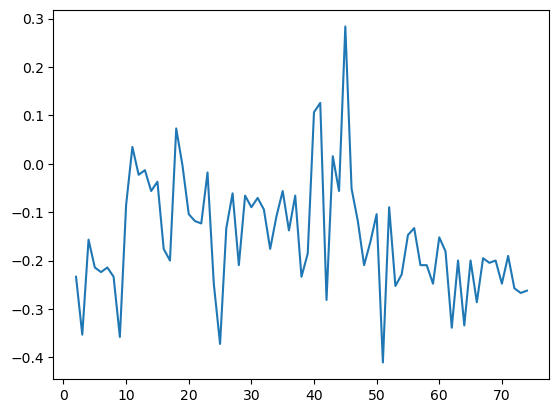

In [11]:
import matplotlib.pyplot as plt 

plt.plot(df['accX'])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks


def safe_savgol(x, window_length=11, polyorder=2):
    """
    Apply Savitzky-Golay smoothing safely.

    The window length must be:
    - odd
    - <= len(x)
    - > polyorder
    """
    x = np.asarray(x, dtype=float)
    n = len(x)

    if n <= polyorder + 2:
        return x

    window_length = min(window_length, n if n % 2 == 1 else n - 1)

    if window_length <= polyorder:
        return x

    return savgol_filter(x, window_length, polyorder)


def enforce_alternating_extrema(sig_n, peaks, valleys, max_valleys=11):
    """
    Enforce an alternating sequence of extrema.

    This removes:
    - peak -> peak
    - valley -> valley

    If two consecutive peaks occur, keep the higher one.
    If two consecutive valleys occur, keep the deeper one.
    """
    peaks = np.asarray(peaks, dtype=int)
    valleys = np.asarray(valleys, dtype=int)

    extrema = []

    for p in peaks:
        extrema.append((p, "peak"))

    for v in valleys:
        extrema.append((v, "valley"))

    # Sort all extrema by time/sample index
    extrema = sorted(extrema, key=lambda x: x[0])

    cleaned = []

    for idx, kind in extrema:
        if not cleaned:
            cleaned.append((idx, kind))
            continue

        prev_idx, prev_kind = cleaned[-1]

        if kind != prev_kind:
            cleaned.append((idx, kind))
        else:
            # Same type twice in a row: keep the stronger one
            if kind == "peak":
                # Higher peak is stronger
                if sig_n[idx] > sig_n[prev_idx]:
                    cleaned[-1] = (idx, kind)

            elif kind == "valley":
                # Deeper valley is stronger
                if sig_n[idx] < sig_n[prev_idx]:
                    cleaned[-1] = (idx, kind)

    cleaned_peaks = np.array(
        [idx for idx, kind in cleaned if kind == "peak"],
        dtype=int
    )

    cleaned_valleys = np.array(
        [idx for idx, kind in cleaned if kind == "valley"],
        dtype=int
    )

    # Limit the number of valleys
    if len(cleaned_valleys) > max_valleys:
        deepest = np.argsort(sig_n[cleaned_valleys])[:max_valleys]
        cleaned_valleys = np.sort(cleaned_valleys[deepest])

        # Re-apply alternation after removing excess valleys
        return enforce_alternating_extrema(
            sig_n=sig_n,
            peaks=cleaned_peaks,
            valleys=cleaned_valleys,
            max_valleys=max_valleys
        )

    return cleaned_peaks, cleaned_valleys


def detect_peaks_and_valleys_clean(
    used,
    expected_reps=10,
    max_valleys=11,
    window_length=11,
    polyorder=2,
    peak_prominence=0.5,
    valley_prominence=0.5,
    plot=True
):
    """
    Detect clean repetition peaks and valleys from the most active gyroscope unit.

    Assumption:
        One repetition has the form

            valley -> peak -> valley

    Therefore:
        - there cannot be two consecutive peaks
        - there cannot be two consecutive valleys
        - max number of valleys is usually expected_reps + 1

    Parameters
    ----------
    used : pandas.DataFrame
        Data for one subject-exercise-label combination.
    u : str
        Unit name, for example "u2".
    expected_reps : int
        Expected number of repetitions.
    max_valleys : int
        Maximum allowed number of valleys. For 10 repetitions, usually 11.
    window_length : int
        Savitzky-Golay smoothing window.
    polyorder : int
        Savitzky-Golay polynomial order.
    peak_prominence : float
        Prominence threshold for peaks.
    valley_prominence : float
        Prominence threshold for valleys.
    plot : bool
        Whether to plot the detected extrema.

    Returns
    -------
    peaks : np.ndarray
        Clean peak indices, relative to `used`.
    valleys : np.ndarray
        Clean valley indices, relative to `used`.
    info : dict
        Diagnostic information.
    """

    time = used["computer_time"].to_numpy()

    # Smooth gyroscope axes
    gx = safe_savgol(
        used[f"accX"].to_numpy(),
        window_length=window_length,
        polyorder=polyorder
    )

    gy = safe_savgol(
        used[f"accY"].to_numpy(),
        window_length=window_length,
        polyorder=polyorder
    )

    gz = safe_savgol(
        used[f"accZ"].to_numpy(),
        window_length=window_length,
        polyorder=polyorder
    )

    signals = {
        "x": gx,
        "y": gy,
        "z": gz
    }

    # Choose the axis with the largest oscillation
    axis = max(signals, key=lambda a: np.ptp(signals[a]))
    sig = signals[axis]

    # Normalize signal
    std = np.std(sig)

    if std == 0:
        sig_n = sig - np.mean(sig)
    else:
        sig_n = (sig - np.mean(sig)) / std

    # Estimate minimum distance between extrema in samples
    expected_period = len(sig_n) / expected_reps
    distance = max(1, int(0.5 * expected_period))

    # Detect candidate peaks
    peaks, peak_props = find_peaks(
        sig_n,
        distance=distance,
        prominence=peak_prominence
    )

    # Detect candidate valleys
    valleys, valley_props = find_peaks(
        -sig_n,
        distance=distance,
        prominence=valley_prominence
    )

    # Enforce:
    #   no peak -> peak
    #   no valley -> valley
    #   max number of valleys
    peaks, valleys = enforce_alternating_extrema(
        sig_n=sig_n,
        peaks=peaks,
        valleys=valleys,
        max_valleys=max_valleys
    )

    info = {
        "axis": axis,
        "n_peaks": len(peaks),
        "n_valleys": len(valleys),
        "expected_reps": expected_reps,
        "max_valleys": max_valleys,
        "distance": distance,
        "peak_prominence": peak_prominence,
        "valley_prominence": valley_prominence
    }

    if len(valleys)!=11:
        plt.figure(figsize=(12, 4))

        plt.plot(
            time,
            sig_n,
            label=f"normalized gyr_{axis}"
        )

        plt.plot(
            time[peaks],
            sig_n[peaks],
            "o",
            label="clean peaks"
        )

        plt.plot(
            time[valleys],
            sig_n[valleys],
            "x",
            label="clean valleys"
        )

        plt.title(
            f"axis={axis}, "
            f"peaks={len(peaks)}, valleys={len(valleys)}, "
            f"expected={expected_reps}"
        )

        plt.xlabel("computer_time")
        plt.ylabel("normalized signal")
        plt.legend()
        plt.show()

    return peaks, valleys, info

In [40]:
df = df.dropna()

In [41]:
df

,computer_time,accX,accY,accZ
2,1.779799e+09,-0.233300,4.544568,8.776276
3,1.779799e+09,-0.352941,4.630710,8.876774
4,1.779799e+09,-0.156730,4.606782,8.790632
5,1.779799e+09,-0.214158,4.616353,8.809774
6,1.779799e+09,-0.223729,4.573282,8.943773
...,...,...,...,...
70,1.779799e+09,-0.247657,4.070789,9.072986
71,1.779799e+09,-0.190229,4.080361,9.020343
72,1.779799e+09,-0.257228,4.104289,9.015557
73,1.779799e+09,-0.266800,4.085146,9.154342


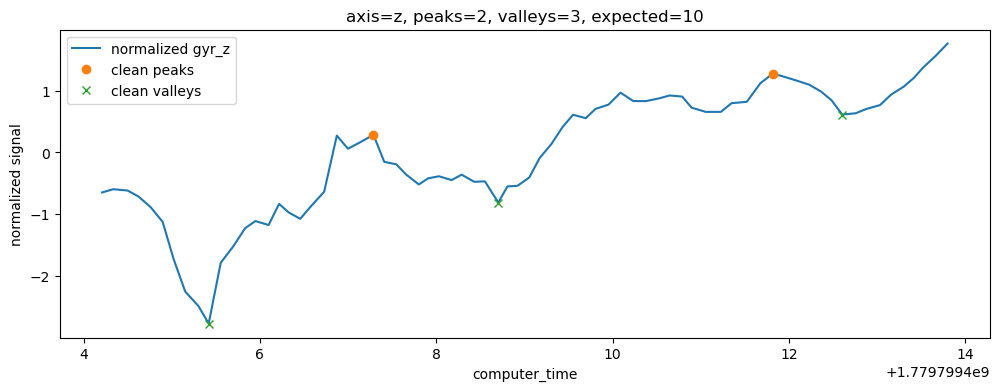

(array([23, 57]),
 array([ 9, 34, 63]),
 {'axis': 'z',
  'n_peaks': 2,
  'n_valleys': 3,
  'expected_reps': 10,
  'max_valleys': 11,
  'distance': 3,
  'peak_prominence': 0.5,
  'valley_prominence': 0.5})

In [42]:
detect_peaks_and_valleys_clean(df)